# Prep 3 · Bayesian inference by hand

**Time:** about 90 minutes. **Needs:** NumPy and matplotlib only — no JAX, no NumPyro.

Bayes' rule in one line:

$$p(\text{unknown} \mid \text{data}) \;\propto\; p(\text{data} \mid \text{unknown}) \; p(\text{unknown})$$

**posterior ∝ likelihood × prior.** The prior says what you believed before; the likelihood says how well
each candidate value explains the data; the posterior is what you believe afterwards. Everything in this
notebook is computed on a **grid** — brute force, no libraries — so there is nothing to trust but
arithmetic. By the end you will have solved the MRI reconstruction problem in two pixels.

In [1]:
import this


The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


In [2]:
import antigravity

In [3]:
from cmath import exp
from distutils.command import check

import numpy as np
import matplotlib.pyplot as plt

## 1. A coin

We flip a coin 10 times and see 7 heads. What is the probability of heads, `p`?

- **Unknown:** `p ∈ [0, 1]`. We lay a grid of 1001 candidate values.
- **Prior:** we know nothing, so every `p` is equally likely (uniform).
- **Likelihood:** the probability of the data for a given `p`: `p^7 (1 − p)^3` (up to a constant).
- **Posterior:** multiply, then normalise so it sums to 1.

In [4]:
p = np.linspace(0, 1, 1001)
prior = np.ones_like(p)                     # uniform
likelihood = p ** 7 * (1 - p) ** 3          # 7 heads, 3 tails

### Exercise 1 — the posterior on a grid

Write `grid_posterior(prior, likelihood)` returning the normalised posterior (it must sum to 1), then
compute the **MAP** (the grid value where the posterior is highest) and the **posterior mean**
(`Σ p · posterior`). They differ — think about why.

In [5]:
def grid_posterior(prior, likelihood):
    post = prior * likelihood
    return post/post.sum()

    # YOUR CODE HERE
    ...

posterior = grid_posterior(prior, likelihood)
p_map = p[np.argmax(posterior)]   # YOUR CODE HERE: the MAP
p_mean = np.sum(p * posterior)    # YOUR CODE HERE: the posterior mean

<details><summary><b>Hint</b> — try the exercise first, then click to reveal</summary>

Bayes' rule on a grid is one multiplication: `post = prior * likelihood`, then divide by `post.sum()`
so it is a proper distribution. The MAP is the grid value at the peak — `p[np.argmax(posterior)]` —
and the mean is the probability-weighted average, `np.sum(p * posterior)`.

</details>

MAP = 0.700   posterior mean = 0.667


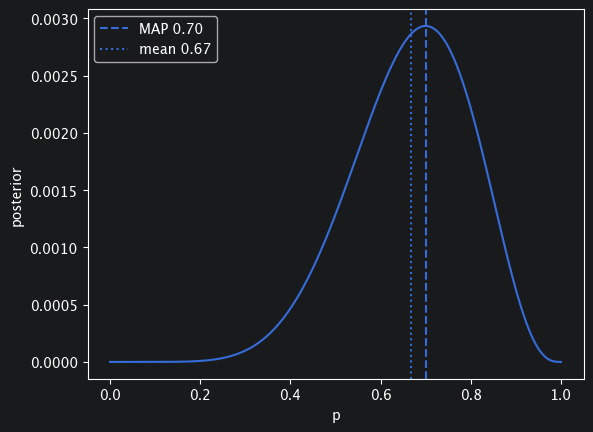

exercise 1 OK


In [6]:
assert posterior is not ... and p_map is not ... and p_mean is not ..., "fill in the exercise above first"
print(f"MAP = {p_map:.3f}   posterior mean = {p_mean:.3f}")
plt.plot(p, posterior); plt.axvline(p_map, ls="--", label=f"MAP {p_map:.2f}"); plt.axvline(p_mean, ls=":", label=f"mean {p_mean:.2f}")
plt.xlabel("p"); plt.ylabel("posterior"); plt.legend(); plt.show()

# check (the exact answers: MAP = 7/10, mean = 8/12)
assert abs(posterior.sum() - 1) < 1e-9                     # it really is normalised
assert abs(p_map - 0.7) < 0.005 and abs(p_mean - 2 / 3) < 0.005
print("exercise 1 OK")

### The prior matters when data are scarce — and stops mattering when they are not

Same coin, three priors: uniform, mildly-fair (`p(1−p)`), strongly-fair (`p^20 (1−p)^20`). With 10 flips the
posteriors disagree; with 1000 flips (700 heads) they agree. **This is the whole game in MRI:** with
little data (an undersampled scan) the prior decides; our job is to learn a prior that is *right*.

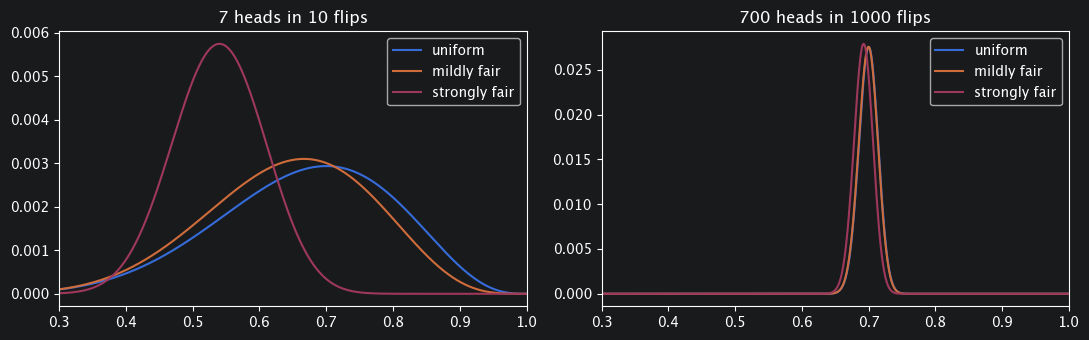

In [7]:
assert grid_posterior(prior, likelihood) is not None, "finish exercise 1 first"
priors = {"uniform": np.ones_like(p), "mildly fair": p * (1 - p), "strongly fair": p ** 20 * (1 - p) ** 20}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for a, (h, n_flips) in zip(ax, ((7, 10), (700, 1000))):
    like = np.exp(h * np.log(p + 1e-12) + (n_flips - h) * np.log(1 - p + 1e-12))
    for name, pr in priors.items():
        a.plot(p, grid_posterior(pr, like), label=name)
    a.set_title(f"{h} heads in {n_flips} flips"); a.set_xlim(0.3, 1); a.legend()
plt.tight_layout(); plt.show()

## 2. Denoising one number — the prior *shrinks*

Now a continuous unknown: a true value `x` with prior `x ~ N(0, τ²)`, and a noisy measurement
`y = x + ε`, `ε ~ N(0, σ²)`. This has a closed form — the posterior is Gaussian with

$$\text{mean} = \frac{\tau^2}{\tau^2 + \sigma^2}\, y, \qquad \text{std} = \Big(\frac{1}{\tau^2} + \frac{1}{\sigma^2}\Big)^{-1/2}$$

so the estimate is the measurement **shrunk toward the prior mean**, by an amount set by how noisy the
data are relative to how confident the prior is.

### Exercise 2 — check the formula on a grid

With `τ = 1, σ = 0.5, y = 1.2`, compute the posterior on the grid `xs` (Gaussian prior × Gaussian
likelihood), then its mean and standard deviation. Compare to the formula.

In [9]:
tau, sigma, y = 1.0, 0.5, 1.2
xs = np.linspace(-4, 4, 4001)

prior_x = ...    # YOUR CODE HERE: Gaussian prior density on xs (unnormalised is fine)
like_x = ...      # YOUR CODE HERE: Gaussian likelihood of y for each xs
post_x = grid_posterior(prior_x, like_x)

post_mean = ...   # YOUR CODE HERE
post_std = ...    # YOUR CODE HERE

TypeError: unsupported operand type(s) for *: 'ellipsis' and 'ellipsis'

<details><summary><b>Hint</b> — try the exercise first, then click to reveal</summary>

Both densities are Gaussians evaluated on the grid, unnormalised is fine:
`np.exp(-0.5 * xs**2 / tau**2)` for the prior and `np.exp(-0.5 * (y - xs)**2 / sigma**2)` for the
likelihood. The mean is `np.sum(xs * post_x)` (like exercise 1), and the std is the square root of
the variance `np.sum((xs - post_mean)**2 * post_x)`.

</details>

In [ ]:
assert post_mean is not ... and post_std is not ..., "fill in the exercise above first"
formula_mean = tau ** 2 / (tau ** 2 + sigma ** 2) * y
formula_std = (1 / tau ** 2 + 1 / sigma ** 2) ** -0.5
print(f"grid: mean {post_mean:.3f}, std {post_std:.3f}   formula: mean {formula_mean:.3f}, std {formula_std:.3f}")
plt.plot(xs, prior_x / prior_x.sum(), label="prior"); plt.plot(xs, like_x / like_x.sum(), label="likelihood"); plt.plot(xs, post_x, label="posterior")
plt.axvline(y, color="k", ls=":", label="measurement y"); plt.xlim(-2.5, 3); plt.legend(); plt.show()

assert abs(post_mean - formula_mean) < 0.01 and abs(post_std - formula_std) < 0.01
print("exercise 2 OK")

## 3. The whole project in two pixels

An "image" with two pixels, `x = (x₁, x₂)`. The "scanner" measures only their **sum**:
`y = x₁ + x₂ + ε`, `ε ~ N(0, σ²)`, and we observe `y = 1.0`.

One number measured, two unknown: **ill-posed**. The likelihood alone can't tell `(0.2, 0.8)` from
`(0.8, 0.2)` from `(5, −4)` — it is a *ridge* in the `(x₁, x₂)` plane. A prior turns the ridge into a bump:

- **Prior A (independent):** `x₁, x₂ ~ N(0, 1)` each.
- **Prior B (smooth):** the same, plus `x₁ − x₂ ~ N(0, 0.1²)` — "neighbouring pixels are similar".

This is exactly undersampled MRI: the measurement pins down some directions of image space, the prior
has to supply the rest, and the posterior *width* tells you which directions you should not trust.

In [ ]:
sigma_y, y_obs = 0.1, 1.0
g = np.linspace(-4, 4, 801)          # wide enough that the prior is not cut off
X1, X2 = np.meshgrid(g, g, indexing="ij")

likelihood_2d = np.exp(-0.5 * (y_obs - (X1 + X2)) ** 2 / sigma_y ** 2)     # a ridge
prior_A = np.exp(-0.5 * (X1 ** 2 + X2 ** 2))
prior_B = prior_A * np.exp(-0.5 * (X1 - X2) ** 2 / 0.1 ** 2)

plt.figure(figsize=(4, 4)); plt.contourf(g, g, likelihood_2d.T, 20); plt.xlim(-2, 2); plt.ylim(-2, 2); plt.title("likelihood alone: a ridge"); plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

### Exercise 3 — posterior, MAP, and per-pixel uncertainty under each prior

For each prior compute the normalised 2-D posterior, its MAP `(x₁, x₂)`, and the **marginal** mean and
standard deviation of each pixel (sum the posterior over the *other* axis first). Fill in `summarise`.
Then look at the numbers: which prior leaves the pixels more uncertain, and why?

In [ ]:
def summarise(prior):
    post = prior * likelihood_2d
    post = ...            # YOUR CODE HERE: normalise
    assert post is not ..., "normalise `post` first"
    i, j = np.unravel_index(np.argmax(post), post.shape)
    x_map = np.array([g[i], g[j]])
    m1, m2 = ..., ...     # YOUR CODE HERE: the marginals of x1 and x2
    mean = ...           # YOUR CODE HERE: array of the two marginal means
    std = ...             # YOUR CODE HERE: array of the two marginal standard deviations
    return post, x_map, mean, std

<details><summary><b>Hint</b> — try the exercise first, then click to reveal</summary>

To marginalise a pixel out, sum the 2-D posterior over *its* axis: `post.sum(axis=1)` is the marginal
of `x₁` (axis 0 indexes `x₁` — we built the grid with `indexing="ij"`), `post.sum(axis=0)` that of
`x₂`. Each marginal is a 1-D distribution over `g`, so its mean and std follow exactly the
exercise-2 pattern.

</details>

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
results = {}
for a, (name, pr) in zip(ax, (("A: independent", prior_A), ("B: smooth", prior_B))):
    post, x_map, mean, std = summarise(pr)
    assert post is not ... and mean is not ... and std is not ..., "fill in summarise() above first"
    results[name] = (x_map, mean, std)
    a.contourf(g, g, post.T, 20); a.plot(*x_map, "r+", ms=12); a.set_title(f"prior {name}\nMAP {np.round(x_map, 2)}, std {np.round(std, 2)}")
    a.set_xlabel("x1"); a.set_ylabel("x2"); a.set_xlim(-2, 2); a.set_ylim(-2, 2)
plt.tight_layout(); plt.show()

# check
(map_A, mean_A, std_A), (map_B, mean_B, std_B) = results.values()
assert np.allclose(map_A, [0.5, 0.5], atol=0.03) and np.allclose(map_B, [0.5, 0.5], atol=0.03), "both MAPs sit at (0.5, 0.5)"
assert np.all(std_B < std_A), "the smoothness prior should make each pixel LESS uncertain"
assert abs(std_A[0] - 0.71) < 0.03, "under prior A each pixel has std ~0.71: the unmeasured direction keeps its prior width"
print("exercise 3 OK ·  per-pixel std: A", np.round(std_A, 2), " B", np.round(std_B, 2))

## What you just did *is* the project

| here | at the school |
|---|---|
| `(x₁, x₂)` | a 128 × 128 image |
| `y = x₁ + x₂` | `y = M ⊙ fft2c(x)`, the undersampled k-space |
| prior A / prior B | a β-VAE decoder trained on knees |
| the MAP (red cross) | the MAP reconstruction (notebook 03) |
| the per-pixel std | the uncertainty map (notebook 04) |

One thing does **not** scale: the grid. Two pixels needed 801² ≈ 640 000 grid points; 128 latent
dimensions would need 801¹²⁸. That is why the real thing uses **MCMC** — a sampler that explores the
posterior instead of tabulating it. Next notebook.

## Done when

- all three checks print OK;
- you can explain the difference between the MAP and the posterior mean, and why prior B reduced the
  per-pixel uncertainty (it removed the direction the data never measured).

In [ ]:
"""
NumPy ndarray + FFT playground
------------------------------
Everything from the explanation, as runnable code you can poke at.
Run cell by cell, or top-to-bottom. Requires only numpy.
"""

import numpy as np

# ============================================================
# 1. THE ndarray: buffer + metadata (shape, strides, dtype)
# ============================================================

# Build from a Python sequence
a = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
print("a               :", a)
print("a.shape         :", a.shape)
print("a.dtype         :", a.dtype)
print("a.ndim          :", a.ndim)
print("a.size          :", a.size)
print("a.strides (bytes):", a.strides)

# A 2-D array. Note strides = (row bytes, col bytes)
M = np.arange(20, dtype=np.float64).reshape(4, 5)
print("\nM:\n", M)
print("M.shape   :", M.shape)
print("M.strides :", M.strides, "  # (4*8, 8) = (32, 8)")

# Contiguity check
print("M.flags['C_CONTIGUOUS']:", M.flags["C_CONTIGUOUS"])

In [ ]:
zeros   = np.zeros((2, 3))
ones    = np.ones((2, 3))
empty   = np.empty((2, 3))            # uninitialized (garbage until you fill it)
arange  = np.arange(0, 1, 0.2)        # like range(), returns array
linspace= np.linspace(0, 1, 6)       # 11 points, endpoints inclusive
full    = np.full((2, 3), 7.0)
eye     = np.eye(3)
rng     = np.random.default_rng(0)
normal  = rng.normal(size=(2, 3))

print("\nzeros:\n", zeros)
print("arange:", arange)
print("linspace:", linspace)
print("Ones:\n", ones)
print("empty:\n", empty)
print("Eye")

In [ ]:
x = np.arange(10, dtype=np.float64)
print("\nx:", x)

v = x[5:8]                 # VIEW into x's buffer
v[0] = 999.0               # mutates x!
print("after v[0]=999, x:", x)

In [ ]:
c = x[2:6].copy()          # COPY, independent buffer
c[0] = -1.0
print("after c[0]=-1, x :", x, " (unchanged)")

# A transpose is also a view: no data moves, only strides change
print("\nM.T.shape:", M.T.shape, " M.T.strides:", M.T.strides)
print("Same buffer? np.shares_memory(M, M.T):", np.shares_memory(M, M.T))

# Strided slice (every other element)
print("x[::2]:", x[::2], " strides:", x[::2].strides)

In [ ]:
col = np.arange(3).reshape(3, 1)   # shape (3,1)
row = np.arange(4).reshape(1, 4)   # shape (1,4)
outer = col + row                  # shape (3,4), no copies of the inputs
print("\ncol+row (outer):\n", outer)
print("shape:", outer.shape)

# Broadcasting does NOT copy the stretched operand:
big   = np.ones((1000, 1))
small = np.arange(5).reshape(1, 5)
res   = big * small                # (1000,5) result, but "big" was never expanded
print("broadcast result shape:", res.shape)


In [ ]:

# Centering columns via broadcast + reduction
X = rng.normal(size=(5, 3))
Xc = X - X.mean(axis=0)            # mean over rows -> shape (3,), broadcast over rows
print("\ncolumn means after centering:", Xc.mean(axis=0))

# ============================================================
# 5. REDUCTIONS & LINEAR ALGEBRA
# ============================================================

A = np.arange(12, dtype=np.float64).reshape(3, 4)
print("\nA:\n", A)
print("A.sum()        :", A.sum())
print("A.mean(axis=0) :", A.mean(axis=0), "  # per-column mean")
print("A.mean(axis=1) :", A.mean(axis=1), "  # per-row mean")
print("A.std()        :", A.std())

u = np.array([1.0, 2.0, 3.0])
v2 = np.array([4.0, 5.0, 6.0])
print("\nu @ v2 (inner product):", u @ v2)
print("np.dot(u, v2)        :", np.dot(u, v2))

B = rng.normal(size=(4, 2))
print("A @ B shape:", (A @ B).shape)   # (3,4)@(4,2) -> (3,2)


In [ ]:


N  = 1024
dt = 1.0 / N                        # sample spacing
t  = np.arange(N) * dt
f0 = 50.0                           # signal frequency (cycles per unit time)

sig = np.sin(2 * np.pi * f0 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Full complex FFT
X = np.fft.fft(sig)
freqs_full = np.fft.fftfreq(N, d=dt)          # cycles per unit time
mag_full   = np.abs(X)

# Real-input FFT: half the output, half the memory
Xr = np.fft.rfft(sig)
freqs_r = np.fft.rfftfreq(N, d=dt)
mag_r   = np.abs(Xr)

print("\nfft output length :", X.shape)       # (1024,)
print("rfft output length:", Xr.shape)       # (513,)
print("dominant freq (rfft):", freqs_r[np.argmax(mag_r)])

In [ ]:





# ============================================================
# 4. BROADCASTING
# ============================================================



# ============================================================
# 7. WINDOWING + LEAKAGE
# ============================================================

win      = np.hanning(N)
sig_win  = sig * win
mag_win  = np.abs(np.fft.rfft(sig_win))
print("\npeak magnitude, rectangular window:", mag_r.max())
print("peak magnitude, Hann window       :", mag_win.max())

# ============================================================
# 8. FILTERING IN THE FREQUENCY DOMAIN
# ============================================================

# Low-pass: keep only bins below a cutoff, zero the rest
cutoff_hz   = 80.0
mask        = freqs_r <= cutoff_hz
Xr_filtered = Xr * mask

sig_lp = np.fft.irfft(Xr_filtered, n=N)      # n=N reconstructs full length
print("\nlow-passed signal: shape", sig_lp.shape,
      " rms diff from original:", np.sqrt(np.mean((sig_lp - sig) ** 2)))

# ============================================================
# 9. FFT-BASED CONVOLUTION  O(N log N)
# ============================================================

a_sig = rng.normal(size=256)
b_sig = rng.normal(size=64)

n_conv = len(a_sig) + len(b_sig) - 1          # linear convolution length

A_f = np.fft.rfft(a_sig, n=n_conv)
B_f = np.fft.rfft(b_sig, n=n_conv)
conv_fft = np.fft.irfft(A_f * B_f, n=n_conv)

conv_direct = np.convolve(a_sig, b_sig)       # reference
print("\nfft-conv vs np.convolve max abs diff:",
      np.max(np.abs(conv_fft - conv_direct)))

# ============================================================
# 10. 2-D FFT (images / per-pixel fields)
# ============================================================

img = rng.normal(size=(64, 64))
F2  = np.fft.fft2(img)
F2s = np.fft.fftshift(F2)                     # zero-freq to center, for viewing
recon = np.fft.ifft2(F2).real                 # inverse
print("\nfft2 shape:", F2.shape,
      " reconstruction err:", np.max(np.abs(recon - img)))

# Remember: ifftshift before ifft if you fftshifted the spectrum
recon2 = np.fft.ifft2(np.fft.ifftshift(F2s)).real
print("round-trip with shift/ifftshift err:", np.max(np.abs(recon2 - img)))

# ============================================================
# 11. NULL SPACE / PRIOR INTUITION (tie-in to earlier discussion)
# ============================================================
# A convolution forward model is diagonalized by the FFT.
# Frequency bins where the transfer function H(f) = 0 are the "null space":
# the data never measured them, so the likelihood is flat there.
# A prior supplies precision in those bins.

kernel   = np.array([1.0, 1.0, 1.0, 1.0]) / 4.0     # a moving-average blur
K_full   = np.fft.rfft(kernel, n=N)
H_mag    = np.abs(K_full)
null_bins = np.where(H_mag < 1e-8)[0]
print("\nnumber of null / near-null frequency bins:", null_bins.size)
print("(these are the directions the data never measured)")

# A simple prior: add small precision everywhere in frequency space
prior_precision = 1e-3
posterior_H = (H_mag ** 2) / (H_mag ** 2 + prior_precision)
print("posterior gain in a null bin:", posterior_H[null_bins[0]] if null_bins.size else "n/a")
print("posterior gain in a strong bin:", posterior_H[np.argmax(H_mag)])